# RF PIE He-on-W OpenEdge test case

Probe-derived He plasma, SI geometry, per-tile DC/RF waveform, RustBCA He-on-W data, sputtered-W source, and transport diagnostics.

In [1]:
from pathlib import Path
import glob, json, re
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

case = Path.cwd().resolve()
if case.name == 'scripts':
    case = case.parent
if not (case / 'input/config.json').exists():
    case = Path('examples/workflows/impurity_transport/rfpie_tungsten_transport').resolve()
process_path = next(p / 'database/processes.h5' for p in case.parents
                    if (p / 'database/processes.h5').exists())
assert process_path.exists(), f'Missing OpenEdge process database: {process_path}'
# data source for all dump-reading cells: cloud hi-stat run when present
# ('output_hires_cloud' 600us/15x markers; 'output_cloud' 200us; 'output' local)
DATADIR = case/'output_ramp_cloud'   # z-ramped ne: LP at target, RF column aloft (send-to-Curt run)
if not DATADIR.exists(): DATADIR = case/'output'
print('DATADIR:', DATADIR.name)
cfg = json.loads((case / 'input/config.json').read_text())
summary = json.loads((case / 'input/geometry_summary.json').read_text())

def read_dump(path):
    lines = Path(path).read_text().splitlines()
    step = int(lines[1]); count = int(lines[3])
    columns = lines[8].split()[2:]
    if count:
        values = np.asarray([[float(v) for v in row.split()]
                             for row in lines[9:9+count]])
    else:
        values = np.empty((0, len(columns)))
    return step, {name: values[:, i] for i, name in enumerate(columns)}

print('case:', case)
print(json.dumps(summary, indent=2))

plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "axes.titlesize": 13,
                     "xtick.labelsize": 11, "ytick.labelsize": 11})

def style_fig(fig, grid=True):
    for ax in fig.get_axes():
        if getattr(ax, "_colorbar", None) is not None or ax.get_label() == "<colorbar>":
            continue
        ax.minorticks_on()
        ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
        if grid:
            ax.grid(True, linestyle="--", alpha=0.3)


DATADIR: output
case: /global/u1/d/diawa/OpenEdge/examples/workflows/impurity_transport/rfpie_tungsten_transport
{
  "source_units": "mm",
  "output_units": "m",
  "domain_triangles": 1000,
  "target_face_triangles": 300,
  "target_face_source_triangles": 58,
  "target_face_radial_rings": 5,
  "target_body_triangles": 178,
  "target_body_id_range": [
    1,
    178
  ],
  "target_face_id_range": [
    179,
    478
  ],
  "target_face_area_m2": 0.0004096833213464224,
  "target_z_m": 0.0019049999713897706,
  "domain_bounds_m": [
    [
      -0.03,
      -0.02999067497253418,
      -0.00010000000149011613
    ],
    [
      0.03,
      0.02999067497253418,
      0.059900001525878904
    ]
  ],
  "target_bounds_m": [
    [
      -0.011430000305175781,
      -0.011430000305175781,
      0.0
    ],
    [
      0.011430000305175781,
      0.011430000305175781,
      0.0019049999713897706
    ]
  ],
  "sheath_columns": [
    "Vdc_V",
    "Vrf_peak_V",
    "phase_rad"
  ],
  "sheath_values": [


## 1. Plasma data

Two LP scans averaged and folded about the axis; smooth interpolation in radius; axial profile uniform (no axial measurement).

grid=(121, 161), ne=1.882e+17..2.745e+17 m^-3, Te=3.52..4.08 eV, Ti=0.050 eV
measured edge = 50.0 mm; density tail e-folding length = 10.731 mm
Te fit at measured edge = 4.638 eV, slope = 0.022 eV/mm, tail length = 16.486 mm
density model: C1 PCHIP of log(ne-floor) through folded data; endpoint-slope exponential tail
temperature model: uncertainty-weighted polynomial in r^2; C1 exponential approach to edge asymptote
axial assumption: uniform; LP data provide radial shape only


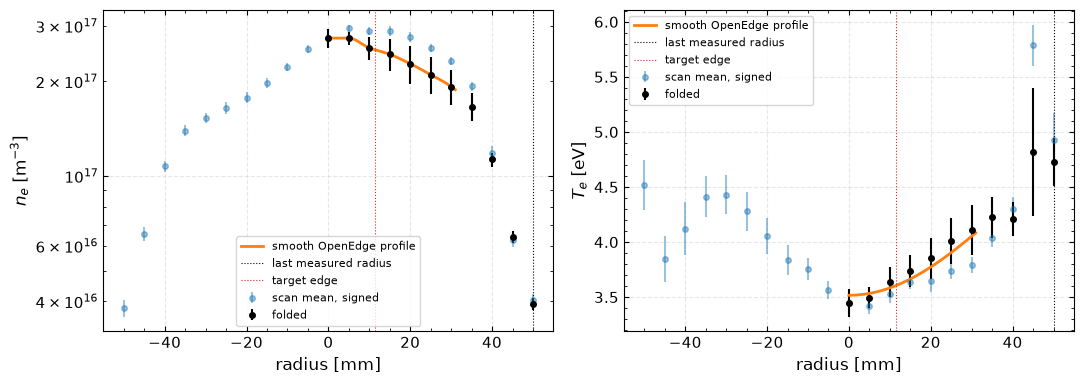

In [2]:
with h5py.File(case / 'input/plasma_he.h5', 'r') as h5:
    r = h5['r'][:]; z = h5['z'][:]
    ne = h5['dens_e'][:]; te = h5['temp_e'][:]; ti = h5['temp_i'][:]
    rs = h5['audit/lp_signed_r_m'][:]
    ne_raw = h5['audit/lp_mean_ne_m3'][:]
    ne_raw_sigma = h5['audit/lp_mean_ne_sigma_m3'][:]
    te_raw = h5['audit/lp_mean_te_eV'][:]
    te_raw_sigma = h5['audit/lp_mean_te_sigma_eV'][:]
    rf = h5['audit/folded_r_m'][:]
    nef = h5['audit/folded_ne_m3'][:]
    nef_sigma = h5['audit/folded_ne_sigma_m3'][:]
    tef = h5['audit/folded_te_eV'][:]
    tef_sigma = h5['audit/folded_te_sigma_eV'][:]
    ne_tail_scale = h5['audit/density_tail_scale_m'][()]
    te_tail_scale = h5['audit/temperature_tail_scale_m'][()]
    te_edge = h5['audit/temperature_edge_eV'][()]
    te_edge_slope = h5['audit/temperature_edge_slope_eV_per_m'][()]
    plasma_attrs = dict(h5.attrs)
    rw = h5['wall_flux/r'][:]
    gamma_he = h5['wall_flux/gamma_i'][0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(rs*1e3, ne_raw, yerr=ne_raw_sigma, fmt='o', alpha=.45,
               ms=4, label='scan mean, signed')
ax[0].errorbar(rf*1e3, nef, yerr=nef_sigma, fmt='ko', ms=4, label='folded')
ax[0].plot(r*1e3, ne[0], lw=2, label='smooth OpenEdge profile')
ax[0].set(xlabel='radius [mm]', ylabel=r'$n_e$ [m$^{-3}$]', yscale='log')
ax[1].errorbar(rs*1e3, te_raw, yerr=te_raw_sigma, fmt='o', alpha=.45,
               ms=4, label='scan mean, signed')
ax[1].errorbar(rf*1e3, tef, yerr=tef_sigma, fmt='ko', ms=4, label='folded')
ax[1].plot(r*1e3, te[0], lw=2, label='smooth OpenEdge profile')
ax[1].set(xlabel='radius [mm]', ylabel=r'$T_e$ [eV]')
for a in ax:
    a.axvline(rf[-1]*1e3, color='k', lw=.8, ls=':', label='last measured radius')
    a.axvline(rw[-1]*1e3, color='tab:red', lw=.8, ls=':', label='target edge')
    a.legend(fontsize=8)
style_fig(fig)
plt.tight_layout()
print(f'grid={ne.shape}, ne={ne.min():.3e}..{ne.max():.3e} m^-3, '
      f'Te={te.min():.2f}..{te.max():.2f} eV, Ti={ti.min():.3f} eV')
print(f'measured edge = {rf[-1]*1e3:.1f} mm; density tail e-folding length = {ne_tail_scale*1e3:.3f} mm')
print(f'Te fit at measured edge = {te_edge:.3f} eV, slope = {te_edge_slope*1e-3:.3f} eV/mm, '
      f'tail length = {te_tail_scale*1e3:.3f} mm')
print('density model:', plasma_attrs['density_model'])
print('temperature model:', plasma_attrs['temperature_model'])
print('axial assumption:', plasma_attrs['assumption_axial_profile'])

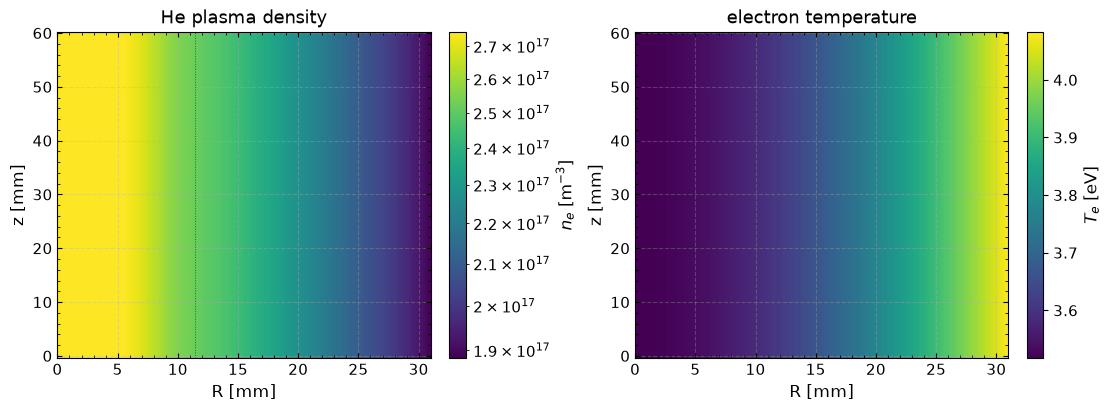

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
im0 = ax[0].pcolormesh(r*1e3, z*1e3, ne, shading='auto',
                       norm=LogNorm(vmin=ne.min(), vmax=ne.max()))
im1 = ax[1].pcolormesh(r*1e3, z*1e3, te, shading='auto')
fig.colorbar(im0, ax=ax[0], label=r'$n_e$ [m$^{-3}$]')
fig.colorbar(im1, ax=ax[1], label=r'$T_e$ [eV]')
ax[0].set_title('He plasma density'); ax[1].set_title('electron temperature')
for a in ax:
    a.axvline(rw[-1]*1e3, color='r', lw=.7, ls=':')
    a.set(xlabel='R [mm]', ylabel='z [mm]', xlim=(0,r[-1]*1e3))
style_fig(fig)


## 2. Geometry and target tiles

The original binary STL coordinates are millimetres. The generated SPARTA
surfaces below are metres. Only the planar +z face is in the sputtering and
sheath group; target sides/back are absorbing but unbiased.

unique [Vdc, Vrf, phase] rows: [[-500.    0.    0.]]


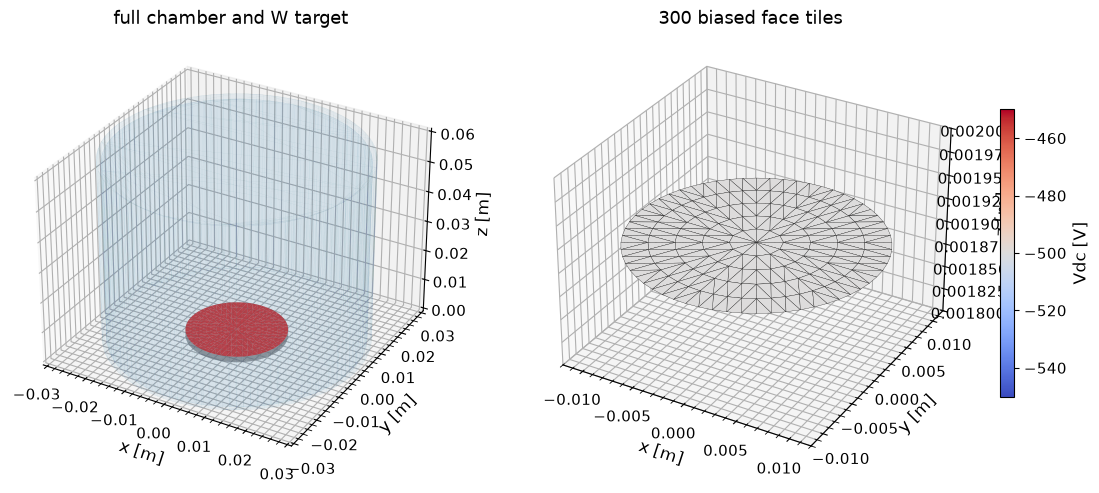

In [4]:
def read_surf(path):
    lines = path.read_text().splitlines()
    npnt = int(next(x.split()[0] for x in lines if x.strip().endswith('points')))
    ntri = int(next(x.split()[0] for x in lines if x.strip().endswith('triangles')))
    ip = lines.index('Points') + 2
    pts = np.array([[float(v) for v in lines[ip+i].split()[1:4]] for i in range(npnt)])
    it = lines.index('Triangles') + 2
    rows = [lines[it+i].split() for i in range(ntri)]
    tri = np.array([[int(v)-1 for v in row[1:4]] for row in rows])
    custom = np.array([[float(v) for v in row[4:]] for row in rows]) if len(rows[0]) > 4 else None
    return pts, tri, custom

pd, td, _ = read_surf(case/'input/domain.surf')
pb, tb, _ = read_surf(case/'input/target_body.surf')
pf, tf, sheath = read_surf(case/'input/target_face.surf')
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121, projection='3d')
ax.add_collection3d(Poly3DCollection(pd[td], facecolor='tab:blue', alpha=.035, edgecolor='tab:blue', linewidth=.12))
ax.add_collection3d(Poly3DCollection(pb[tb], facecolor='0.45', alpha=.45, linewidth=.1))
ax.add_collection3d(Poly3DCollection(pf[tf], facecolor='tab:red', alpha=.85, linewidth=.15))
ax.set(xlim=(-.031,.031), ylim=(-.031,.031), zlim=(-.001,.061), xlabel='x [m]', ylabel='y [m]', zlabel='z [m]', title='full chamber and W target')
ax2 = fig.add_subplot(122, projection='3d')
coll = Poly3DCollection(pf[tf], array=sheath[:,0], cmap='coolwarm', edgecolor='k', linewidth=.2)
ax2.add_collection3d(coll); fig.colorbar(coll, ax=ax2, shrink=.65, label='Vdc [V]')
ax2.set(xlim=(-.012,.012), ylim=(-.012,.012), zlim=(.0018,.0020), xlabel='x [m]', ylabel='y [m]', zlabel='z [m]', title=f'{len(tf)} biased face tiles')
style_fig(fig)
plt.tight_layout()
print('unique [Vdc, Vrf, phase] rows:', np.unique(sheath, axis=0))

## 3. Tile voltage and sheath convention

`Vwall(t) = Vdc + Vrf_peak sin(2 pi f t + phase)`, relative to the local plasma; the sub-grid `sheath boundary` model carries the potential jump. This run is DC (`Vrf = 0`).

RF period=73.746 ns; dt=20.000 ns; steps/period=3.7
grid=(np.int64(64), np.int64(64), np.int64(96)); cell widths [mm]=[0.940625   0.940625   0.62708333]
center Debye length=26.6 um; smallest cell=0.627 mm (24 Debye lengths)
80 eV W full-step/smallest-cell=0.292; Boris-substep/cell=0.146; cross-field RMS step=63.2 um
center He Bohm speed=9.273e+03 m/s; ion plasma frequency=55.07 MHz


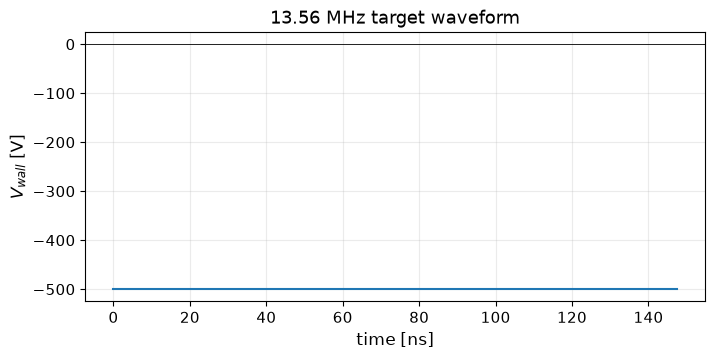

In [5]:
vdc, vrf, phase = sheath[0]
freq = cfg['target_sheath']['frequency_hz']
t = np.linspace(0, 2/freq, 500)
vwall = vdc + vrf*np.sin(2*np.pi*freq*t + phase)
plt.figure(figsize=(8,3.5)); plt.plot(t*1e9, vwall)
plt.axhline(0, color='k', lw=.6); plt.grid(alpha=.25)
plt.xlabel('time [ns]'); plt.ylabel(r'$V_{wall}$ [V]')
plt.title(f'{freq/1e6:.2f} MHz target waveform')
period = 1/freq; dt = cfg['transport']['timestep_s']
print(f'RF period={period*1e9:.3f} ns; dt={dt*1e9:.3f} ns; steps/period={period/dt:.1f}')
EPS0=8.8541878128e-12; QE=1.602176634e-19
mi=4.002602*1.66053906660e-27
lambda_D=np.sqrt(EPS0*te[0,0]/(ne[0,0]*QE))
cs0=np.sqrt((te[0,0]+ti[0,0])*QE/mi)
fpi=np.sqrt(ne[0,0]*QE**2/(EPS0*mi))/(2*np.pi)
grid_cells=np.asarray(cfg['transport']['grid_cells'])
box_lengths=np.array([.0602,.0602,.0602])
cell_widths=box_lengths/grid_cells
dx_min=cell_widths.min()
vmax_w=np.sqrt(2*80*QE/(184*1.66053906660e-27))
step_fraction=vmax_w*dt/dx_min
substep_fraction=step_fraction/cfg['transport']['pusher_subcycles']
diffusion_step=np.sqrt(2*cfg['transport']['d_perp_m2_s']*dt)
print(f'grid={tuple(grid_cells)}; cell widths [mm]={cell_widths*1e3}')
print(f'center Debye length={lambda_D*1e6:.1f} um; smallest cell={dx_min*1e3:.3f} mm '
      f'({dx_min/lambda_D:.0f} Debye lengths)')
print(f'80 eV W full-step/smallest-cell={step_fraction:.3f}; '
      f'Boris-substep/cell={substep_fraction:.3f}; '
      f'cross-field RMS step={diffusion_step*1e6:.1f} um')
print(f'center He Bohm speed={cs0:.3e} m/s; ion plasma frequency={fpi/1e6:.2f} MHz')
if vrf != 0 and period/dt < 20:
    print('WARNING: fewer than 20 steps/RF period; reduce dt for time-resolved RF transport')
style_fig(fig)


## 4. RustBCA He-on-W yield and implied W source

The notebook and OpenEdge both read the installed RustBCA table at
`/surface/sputter/he_on_w/{E,theta,Y}` in `database/processes.h5`.

RustBCA 2.8.4 python bindings, 2000..20000 ions/point shape= (50, 45) Y range= (np.float64(0.0), np.float64(0.4075))


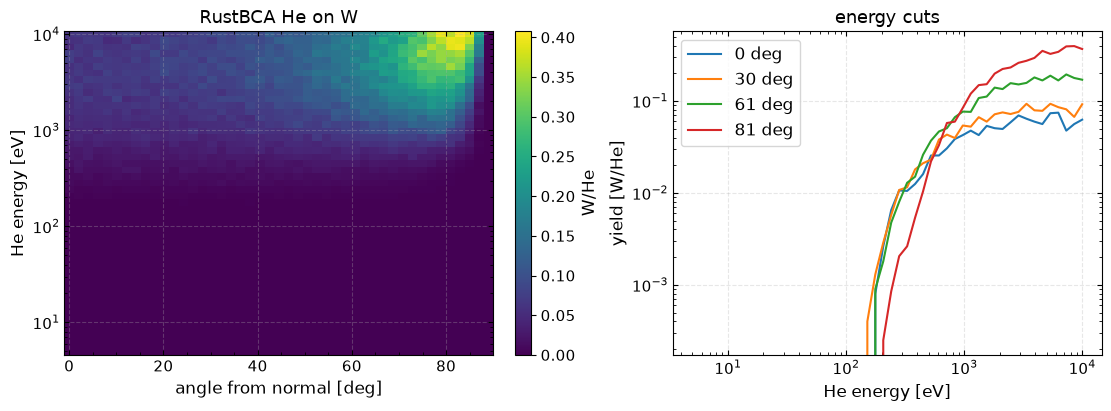

In [6]:
with h5py.File(process_path, 'r') as h5:
    table = h5['surface/sputter/he_on_w']
    Eaxis = table['E'][:]; Aaxis = table['theta'][:]; Y = table['Y'][:]
    table_source = table.attrs.get('source', '')
print(table_source, 'shape=', Y.shape, 'Y range=', (Y.min(),Y.max()))

fig, ax = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
im=ax[0].pcolormesh(Aaxis,Eaxis,Y,shading='auto')
ax[0].set(xlabel='angle from normal [deg]',ylabel='He energy [eV]',yscale='log',title='RustBCA He on W'); fig.colorbar(im,ax=ax[0],label='W/He')
for a in [0,30,60,80]:
    ia=np.argmin(abs(Aaxis-a)); ax[1].plot(Eaxis,Y[:,ia],label=f'{Aaxis[ia]:.0f} deg')
ax[1].set(xlabel='He energy [eV]',ylabel='yield [W/He]',xscale='log',yscale='log',title='energy cuts')
ax[1].grid(alpha=.25); ax[1].legend()
style_fig(fig)


center: Te=3.517 eV, floating drop=12.385 V
center He impact energy: 512.48..512.48 eV
center phase-averaged yield: 0.02404 W/He
integrated sputtered-W source: 2.4331e+16 atoms/s


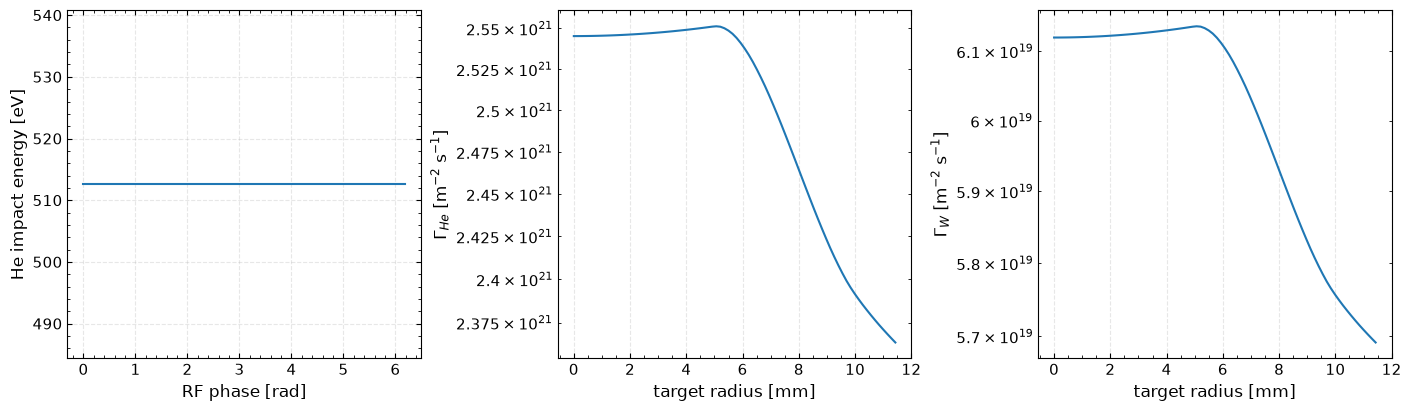

In [7]:
from scipy.interpolate import RegularGridInterpolator
AMU=1.66053906660e-27; ME=9.1093837015e-31
he_amu=4.002602
interpY=RegularGridInterpolator((np.log(Eaxis),Aaxis),Y,bounds_error=False,fill_value=None)

tew=np.interp(rw,r,te[0]); tiw=np.interp(rw,r,ti[0])
psi_over_te=0.5*np.log((he_amu*AMU)/(2*np.pi*ME*(1+tiw/tew)))
nphase=cfg['target_sheath']['phase_samples']
ph=np.linspace(0,2*np.pi,nphase,endpoint=False)
vw=vdc+vrf*np.sin(ph+phase)
Eimpact=2*tiw[:,None]+psi_over_te[:,None]*tew[:,None]+np.maximum(0,-vw)[None,:]
theta=np.zeros_like(Eimpact)  # configured Bz is normal to the planar target
Yphase=interpY(np.column_stack([np.log(np.clip(Eimpact.ravel(),Eaxis[0],Eaxis[-1])),theta.ravel()])).reshape(Eimpact.shape)
ybar=Yphase.mean(axis=1)
gamma_w=gamma_he*ybar

fig,ax=plt.subplots(1,3,figsize=(14,4),constrained_layout=True)
ax[0].plot(ph, Eimpact[len(rw)//2]); ax[0].set(xlabel='RF phase [rad]',ylabel='He impact energy [eV]')
ax[1].plot(rw*1e3,gamma_he); ax[1].set(xlabel='target radius [mm]',ylabel=r'$\Gamma_{He}$ [m$^{-2}$ s$^{-1}$]',yscale='log')
ax[2].plot(rw*1e3,gamma_w); ax[2].set(xlabel='target radius [mm]',ylabel=r'$\Gamma_W$ [m$^{-2}$ s$^{-1}$]',yscale='log')
for a in ax: a.grid(alpha=.25)

rate=2*np.pi*np.trapezoid(gamma_w*rw,rw)
print(f'center: Te={tew[0]:.3f} eV, floating drop={psi_over_te[0]*tew[0]:.3f} V')
print(f'center He impact energy: {Eimpact[0].min():.2f}..{Eimpact[0].max():.2f} eV')
print(f'center phase-averaged yield: {ybar[0]:.4g} W/He')
print(f'integrated sputtered-W source: {rate:.4e} atoms/s')
style_fig(fig)


## 5. ADAS charge-state timescales

The local ionization time is `1 / (ne * SCD_q)`. Comparing it with the run
duration and a simple W flight time explains which charge states can develop.
The coefficients below are exactly the OpenADAS tables used by OpenEdge.

axis W0+ -> W1+ ionization time = 177.04 us
axis W1+ -> W2+ ionization time = 7677.57 us
axis W2+ -> W3+ ionization time = 192911.04 us
axis W3+ -> W4+ ionization time = 33456039.50 us
Thompson mean energy=21.65 eV; straight-line domain flight scale=12.19 us


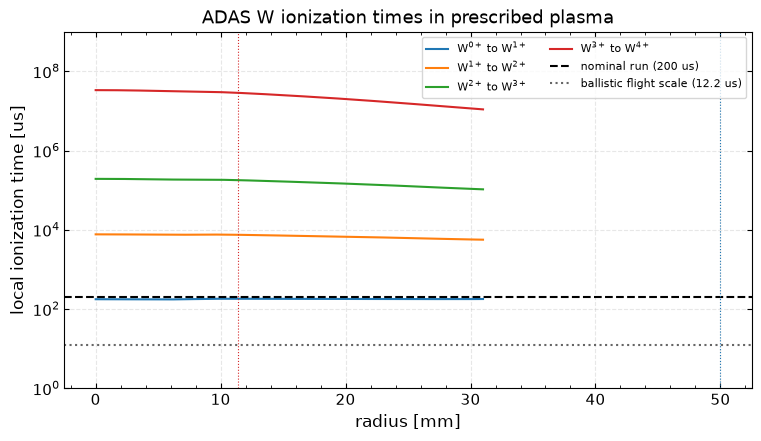

In [8]:
with h5py.File(process_path,'r') as h5:
    scd=h5['volume/rates/scd/w/coefficient'][:]
    scd_te=h5['volume/rates/scd/w/temperature'][:]
    scd_ne=h5['volume/rates/scd/w/density'][:]

log_points=np.column_stack([np.log10(te[0]),np.log10(ne[0]/1e6)])
tau_ion=[]
for charge in range(4):
    log_rate=RegularGridInterpolator((scd_te,scd_ne),scd[charge],
                                     bounds_error=False,fill_value=None)(log_points)
    rate_coefficient_cm3s=10**log_rate
    tau_ion.append(1/(rate_coefficient_cm3s*(ne[0]/1e6)))
tau_ion=np.asarray(tau_ion)

E_th=np.linspace(1e-6,80,2000)
th_pdf=E_th/(E_th+8.68)**3
mean_E=np.trapezoid(E_th*th_pdf,E_th)/np.trapezoid(th_pdf,E_th)
mean_speed=np.sqrt(2*mean_E*QE/(184*AMU))
flight_time=(cfg['plasma']['z_max_m']-summary['target_z_m'])/mean_speed
run_time=cfg['transport']['run_steps']*cfg['transport']['timestep_s']

fig,ax=plt.subplots(figsize=(7.5,4.3),constrained_layout=True)
for charge,tau_q in enumerate(tau_ion):
    ax.semilogy(r*1e3,tau_q*1e6,label=f'W$^{{{charge}+}}$ to W$^{{{charge+1}+}}$')
ax.axhline(run_time*1e6,color='k',ls='--',label=f'nominal run ({run_time*1e6:.0f} us)')
ax.axhline(flight_time*1e6,color='0.4',ls=':',label=f'ballistic flight scale ({flight_time*1e6:.1f} us)')
ax.axvline(rf[-1]*1e3,color='tab:blue',ls=':',lw=.8)
ax.axvline(rw[-1]*1e3,color='tab:red',ls=':',lw=.8)
ax.set(xlabel='radius [mm]',ylabel='local ionization time [us]',
       title='ADAS W ionization times in prescribed plasma',ylim=(1,1e9))
ax.grid(alpha=.25); ax.legend(fontsize=8,ncol=2)
for charge,tau_q in enumerate(tau_ion):
    print(f'axis W{charge}+ -> W{charge+1}+ ionization time = {tau_q[0]*1e6:.2f} us')
print(f'Thompson mean energy={mean_E:.2f} eV; straight-line domain flight scale={flight_time*1e6:.2f} us')
style_fig(fig)


## 6. Gross erosion areal density

This is the gross sputtered-W fluence implied by the prescribed background
over the nominal run time, not net surface evolution. Dividing by bulk W
atomic density gives an equivalent removed depth. Redeposition is presently
absorbing and is not yet accumulated in a surface composition ledger.

nominal emitted W atoms = 4.8663e+12
center gross fluence = 1.2240e+16 m^-2; equivalent depth = 1.9312e-04 nm
No target.0.dump yet; triangle-integrated source check skipped.


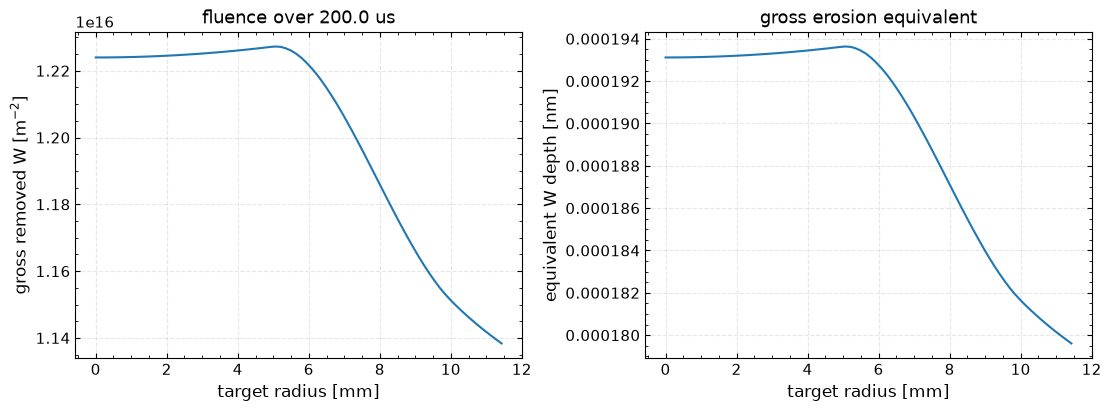

In [9]:
W_BULK_DENSITY=6.338e28  # atoms/m3
nominal_time=cfg['transport']['run_steps']*cfg['transport']['timestep_s']
eroded_areal=gamma_w*nominal_time
equiv_depth_nm=eroded_areal/W_BULK_DENSITY*1e9

fig,ax=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
ax[0].plot(rw*1e3,eroded_areal)
ax[0].set(xlabel='target radius [mm]',ylabel=r'gross removed W [m$^{-2}$]',
          title=f'fluence over {nominal_time*1e6:.1f} us')
ax[1].plot(rw*1e3,equiv_depth_nm)
ax[1].set(xlabel='target radius [mm]',ylabel='equivalent W depth [nm]',
          title='gross erosion equivalent')
for a in ax: a.grid(alpha=.25)
print(f'nominal emitted W atoms = {rate*nominal_time:.4e}')
print(f'center gross fluence = {eroded_areal[0]:.4e} m^-2; '
      f'equivalent depth = {equiv_depth_nm[0]:.4e} nm')

# Once OpenEdge has initialized cpmi, compare its area-by-triangle integral
# against the fine radial quadrature above. This exposes under-resolved tiles.
target_dump=DATADIR/'target.0.dump'
if target_dump.exists():
    _,surf=read_dump(target_dump)
    order=np.argsort(surf['id'])
    face_area=.5*np.linalg.norm(np.cross(pf[tf][:,1]-pf[tf][:,0],
                                        pf[tf][:,2]-pf[tf][:,0]),axis=1)
    oe_rate=np.sum(face_area*surf['c_cpmi'][order])
    print(f'OpenEdge triangle-integrated source = {oe_rate:.4e} atoms/s; '
          f'difference from radial audit = {(oe_rate/rate-1)*100:+.3f}%')
else:
    print('No target.0.dump yet; triangle-integrated source check skipped.')
style_fig(fig)


## 7. Transport diagnostics

R-z total-W map, charge-state profiles on axis, and in-flight W column density from the OpenEdge dumps (no synthetic brightness assumptions).

### 7.1 Load the OpenEdge charge-state density dump

This cell explicitly finds the newest `rfpie_w_density.*.dump` in `DATADIR` (defaults to `output_hires_cloud/` when present, else `output/`), reads
the five `f_fWdens[*]` fields written by `in.openedge`, and prints the selected
file and column names before doing any plotting.

In [10]:
def step_from_name(path):
    match=re.search(r'\.(\d+)\.dump$',str(path))
    return int(match.group(1)) if match else -1

print('loading from:',DATADIR.name)
density_pattern=DATADIR/'rfpie_w_density.*.dump'
density_files=sorted(DATADIR.glob('rfpie_w_density.*.dump'),
                     key=step_from_name)
G=None
dump_dt=cfg['transport']['timestep_s']
dump_grid=np.asarray(cfg['transport']['grid_cells'],dtype=int)
settings_path=DATADIR/'run_settings.txt'
if settings_path.exists():
    dump_settings=dict(token.split('=',1) for token in settings_path.read_text().split())
    dump_dt=float(dump_settings['dt_s'])
    dump_grid=np.array([int(dump_settings[k]) for k in ('nx','ny','nz')])
else:
    dump_settings={}
if not density_files:
    print('No files match:',density_pattern)
    print('Run at least diagnostic_every_steps, then rerun this cell.')
else:
    density_path=density_files[-1]
    step,G=read_dump(density_path)
    labels=['W$^0$','W$^+$','W$^{2+}$','W$^{3+}$','W$^{4+}$']
    fields=[f'f_fWdens[{i}]' for i in range(1,6)]
    dens_species=np.vstack([G[name] for name in fields])
    dens_total=dens_species.sum(axis=0)
    xg,yg,zg,vol=G['xc'],G['yc'],G['zc'],G['vol']
    rg=np.hypot(xg,yg)
    print('loaded:',density_path)
    print('step:',step,'density fields:',fields)
    print('dump settings:',dump_settings if dump_settings else 'not recorded')
    print('dump time:',step*dump_dt*1e6,'us; dump grid:',tuple(dump_grid))
    configured_grid=np.asarray(cfg['transport']['grid_cells'])
    if dump_dt != cfg['transport']['timestep_s'] or np.any(dump_grid != configured_grid):
        print('NOTE: this is an earlier smoke result; current production defaults are',
              f'dt={cfg["transport"]["timestep_s"]*1e9:g} ns, grid={tuple(configured_grid)}')

loading from: output
No files match: /global/u1/d/diawa/OpenEdge/examples/workflows/impurity_transport/rfpie_tungsten_transport/output/rfpie_w_density.*.dump
Run at least diagnostic_every_steps, then rerun this cell.


### 7.2 Plot the densities from that dump

In [11]:
if G is None:
    print('No charge-state density data to plot.')
else:

    nx,ny,nz=dump_grid
    r_edges=np.linspace(0,.0301,nx//2+1)
    z_edges=np.linspace(-.0002,.0600,nz+1)
    atoms_rz=np.histogram2d(rg,zg,bins=[r_edges,z_edges],
                            weights=dens_total*vol)[0]
    volume_rz=np.histogram2d(rg,zg,bins=[r_edges,z_edges],weights=vol)[0]
    dens_rz=np.divide(atoms_rz,volume_rz,out=np.zeros_like(atoms_rz),
                      where=volume_rz>0)

    axis_radius=cfg['transport']['axis_average_radius_m']
    core=rg<=axis_radius
    core_volume=np.histogram(zg,bins=z_edges,weights=vol*core)[0]
    axial=[]
    for ds in dens_species:
        atom_hist=np.histogram(zg,bins=z_edges,weights=ds*vol*core)[0]
        axial.append(np.divide(atom_hist,core_volume,out=np.zeros_like(atom_hist),
                               where=core_volume>0))
    axial=np.asarray(axial)
    zmid=.5*(z_edges[:-1]+z_edges[1:])
    target_z=summary['target_z_m']
    distance_mm=(zmid-target_z)*1e3

    xy_edges=np.linspace(-.0301,.0301,nx+1)
    column_atoms=np.histogram2d(xg,yg,bins=[xy_edges,xy_edges],
                                weights=dens_total*vol)[0]
    dxy=xy_edges[1]-xy_edges[0]
    column_density=column_atoms/dxy**2

    fig,ax=plt.subplots(1,3,figsize=(16,4.3),constrained_layout=True)
    positive=dens_rz[dens_rz>0]
    if positive.size:
        norm=LogNorm(vmin=max(positive.min(),positive.max()*1e-5),vmax=positive.max())
        im=ax[0].pcolormesh(r_edges*1e3,z_edges*1e3,dens_rz.T,
                            shading='auto',norm=norm,cmap='magma')
        fig.colorbar(im,ax=ax[0],label=r'$n_W$ [m$^{-3}$]')
    ax[0].axhline(1.905,color='cyan',ls=':',lw=1)
    ax[0].set(xlabel='R [mm]',ylabel='z [mm]',title='total in-flight W density')

    for profile,label in zip(axial,labels):
        if np.any(profile>0): ax[1].semilogy(distance_mm,np.where(profile>0,profile,np.nan),label=label)
    ax[1].axvline(0,color='k',ls=':',lw=1,label='target face')
    ax[1].set(xlabel='distance from target [mm]',ylabel=r'$\langle n_{W^q}\rangle_{R<3mm}$ [m$^{-3}$]',
              title=f'charge states along axis (R < {axis_radius*1e3:.1f} mm)')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=.25)

    positive=column_density[column_density>0]
    if positive.size:
        norm=LogNorm(vmin=max(positive.min(),positive.max()*1e-5),vmax=positive.max())
        im=ax[2].pcolormesh(xy_edges*1e3,xy_edges*1e3,column_density.T,
                            shading='auto',norm=norm,cmap='viridis')
        fig.colorbar(im,ax=ax[2],label=r'$\int n_W dz$ [m$^{-2}$]')
    ax[2].set(xlabel='x [mm]',ylabel='y [mm]',title='in-flight W column density',aspect='equal')

    inventory=np.sum(dens_species*vol,axis=1)
    total_inventory=inventory.sum()
    print(f'density frame step={step}, t={step*dump_dt*1e6:.3f} us')
    for label,value in zip(labels,inventory):
        print(f'  {label}: {value:.4e} atoms in domain '
              f'({value/total_inventory*100 if total_inventory else 0:.3f}%)')
    target_area=np.pi*rw[-1]**2
    print(f'total in-flight inventory / target area = '
          f'{total_inventory/target_area:.4e} m^-2')

    # Charge-resolved view over the measured spectroscopy distance.  The
    # OpenEdge grid dump above remains the authoritative data product.
    exp_range=(distance_mm>=0)&(distance_mm<=30)
    fig2,ax2=plt.subplots(figsize=(7.5,4.5),constrained_layout=True)
    for profile,label in zip(axial,labels):
        ax2.semilogy(distance_mm[exp_range],
                     np.where(profile[exp_range]>0,profile[exp_range],np.nan),
                     '-o',ms=3,label=label)
    ax2.set(xlabel='distance normal to target [mm]',
            ylabel=r'$\langle n_{W^q}\rangle_{R<3mm}$ [m$^{-3}$]',
            title='OpenEdge W charge-state densities',xlim=(0,30))
    ax2.grid(alpha=.25); ax2.legend(fontsize=8,ncol=2)

    print('authoritative charge-state data:',density_files[-1])
    print(f'profile frame age={step*dump_dt*1e6:.2f} us; '
          f'run >= {flight_time*1e6:.1f} us before interpreting the full axial shape')

    particle_files=sorted(DATADIR.glob('rfpie_w.*.dump'),key=step_from_name)
    if particle_files:
        pstep,P=read_dump(particle_files[-1])
        weighted=np.array([P['p_pweight'][P['type']==i].sum() for i in range(1,6)])
        print(f'latest particle frame step={pstep}; markers={len(P["type"])}; '
              f'pweight charge fractions={weighted/weighted.sum() if weighted.sum() else weighted}')
style_fig(fig)


No charge-state density data to plot.


## 8. W I 498 nm axial emission: GPU vs CPU vs experiment

Peak-normalized W I 498 nm emission along the plume axis, the quantity in Curt's plot
(experiment in black, his models in colour).  Synthetic emission per cell

$\varepsilon = n_{W^0}\, n_e(r)\, \mathrm{PEC}(T_e(r), n_e(r))$

with $n_{W^0}$ from the pweight-aware `fix ave/grid` density dump, $n_e$, $T_e$ from
`input/plasma_he.h5` (uniform in $z$) and the open-ADAS adf15 W I PEC
(`pec40#w_ic#w0.dat`, isel 49, 5000.73 Å theoretical wavelength, taken as the 498 nm line).
`chord` integrates the emission across the plume at each height (|y| < 0.5 mm), i.e. a
spectrometer chord viewing along $x$; `axis` averages over R < 3 mm; `dens` is the bare
$n_{W^0}$ axis profile (the PEC varies by only 6% across the plasma column, so all three
are close).  The experiment curve is `input/experiment_wi498_axial_digitized.csv`,
digitized from Curt's plot screenshot (replace with the measured data when available).

Runs: `RUNS` maps a label to an output directory; missing directories are skipped. Profiles use the mean of the last three density dumps (steps 8000–10000). The z-ramped background (`input/plasma_he_zramp.h5`) follows Curt's setup qualitatively: the LP density at the target face rising to twice that value aloft with a 3 mm e-folding length, Te unchanged.
Production pair (2026-09-11/12, ADAS charge-state model, commit d7ffc5af): the same deck and
settings on one GPU node (4 ranks × A100) and one CPU node (128 MPI ranks): z-ramped
background, `nlaunch_total 5000` (≈4.5 M markers in flight), roulette cap 5000,
128 × 128 × 192 grid, 10 000 steps (200 µs). Earlier 1× and 10× runs on both backends gave
the same profile to within 0.02, so this pair is converged in statistics and grid.

OpenEdge GPU (4 x A100): step 10000, peak at 2.13 mm, value at 5/10/20/30 mm: 0.89 0.61 0.29 0.16


OpenEdge CPU (128 MPI ranks): step 10000, peak at 2.44 mm, value at 5/10/20/30 mm: 0.89 0.61 0.29 0.16


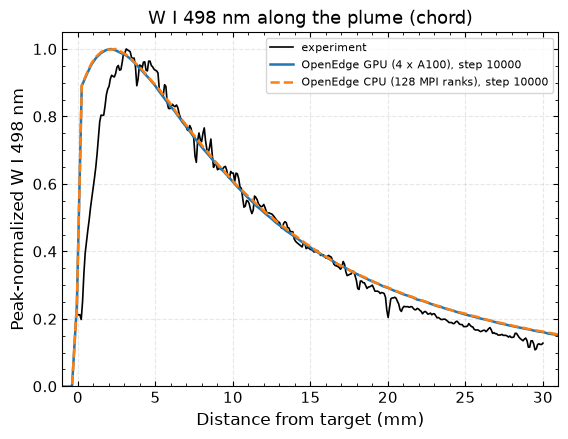

In [12]:
import sys, importlib
sys.path.insert(0, str(case/'scripts'))
import wi498_compare as wc; importlib.reload(wc)

# production runs: runs/<name> symlinks made by scripts/run_{gpu,cpu}_perlmutter.sbatch
# (fallback: the scratch location, then results/<name> which holds only the screens/logs
#  -> performance table works, profiles need the dumps)
def find_run(name):
    for cand in (case/'runs'/name, Path('/pscratch/sd/d/diawa/openedge-runs/rfpie_fix')/name, case/'results'/name):
        if cand.is_dir(): return cand/'output'
    return case/'runs'/name/'output'
RUNS = {
    'OpenEdge GPU (4 x A100)':      find_run('gpu_zramp_hi'),
    'OpenEdge CPU (128 MPI ranks)': find_run('cpu_zramp_hi'),
}
# z-ramped ne: input/plasma_he_zramp.h5 from scripts/build_plasma_zramp.py
# (ne = ne_LP at the target face rising to 2 x ne_LP aloft, e-folding 3 mm; Te unchanged)
PROFILE = 'chord'      # 'chord' | 'axis' | 'dens'
exp = np.loadtxt(case/'input/experiment_wi498_axial_digitized.csv', delimiter=',')

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(exp[:,0], exp[:,1], 'k-', lw=1.2, label='experiment')
styles = ['-', '--', '-.', ':']
results = {}
saved = wc.load_profiles(case/'results/wi498_profiles.csv') if (case/'results/wi498_profiles.csv').exists() else {}
for i, (label, rundir) in enumerate(RUNS.items()):
    if rundir.exists() and list(rundir.glob('rfpie_w_density.*.dump')):
        P = wc.profiles(rundir, wc.plasma_file_for(rundir), summary, last_n=3)
    elif label in saved:
        P = saved[label]; print('no dumps, using results/wi498_profiles.csv:', label)
    else:
        print('skip (no dumps, no saved profile):', label, rundir); continue
    results[label] = P
    ax.plot(P['dist_mm'], P[PROFILE], styles[i % 4], lw=1.8, label=f"{label}, step {P['step']}")
    print(f"{label}: step {P['step']}, peak at {P['dist_mm'][P[PROFILE].argmax()]:.2f} mm, "
          + 'value at 5/10/20/30 mm: ' + ' '.join('%.2f' % np.interp(v, P['dist_mm'], P[PROFILE]) for v in (5, 10, 20, 30)))
if results and all(RUNS[l].exists() for l in results):
    (case/'results').mkdir(exist_ok=True); wc.save_profiles(results, case/'results/wi498_profiles.csv')
ax.set(xlim=(-1, 31), ylim=(0, 1.05), xlabel='Distance from target (mm)', ylabel='Peak-normalized W I 498 nm',
       title=f'W I 498 nm along the plume ({PROFILE})')
ax.legend(fontsize=8); style_fig(fig)
fig.savefig(case/'output/wi498_gpu_cpu_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

OpenEdge CPU (128 MPI ranks) vs OpenEdge GPU (4 x A100): max |diff| = 0.007, rms = 0.003 (peak-normalized units)


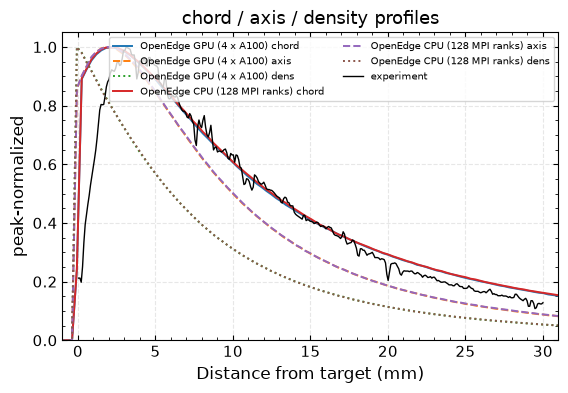

In [13]:
# GPU vs CPU agreement on the same profile, and the emission-model sensitivity
if len(results) >= 2:
    labels = list(results)
    for a in labels:
        for b in labels:
            if a >= b: continue
            Pa, Pb = results[a], results[b]
            common = np.linspace(0.5, 30, 60)
            ya = np.interp(common, Pa['dist_mm'], Pa[PROFILE]); yb = np.interp(common, Pb['dist_mm'], Pb[PROFILE])
            print(f"{a} vs {b}: max |diff| = {np.abs(ya-yb).max():.3f}, rms = {np.sqrt(np.mean((ya-yb)**2)):.3f} (peak-normalized units)")
    fig, ax = plt.subplots(figsize=(6.4, 4))
    for label, P in results.items():
        for prof, ls in (('chord', '-'), ('axis', '--'), ('dens', ':')):
            ax.plot(P['dist_mm'], P[prof], ls, lw=1.4, label=f'{label} {prof}')
    ax.plot(exp[:,0], exp[:,1], 'k-', lw=1.0, label='experiment')
    ax.set(xlim=(-1, 31), ylim=(0, 1.05), xlabel='Distance from target (mm)', ylabel='peak-normalized', title='chord / axis / density profiles')
    ax.legend(fontsize=7, ncol=2); style_fig(fig); plt.show()

## 9. GPU vs CPU performance on this case

Wall time of the main loop, markers in flight and throughput, read from the run screens of the
two production runs above (identical deck, settings and step count; GPU run at commit 1258901b,
CPU run at d7ffc5af). The first 1000 steps on the GPU (31 s) are the ramp-up: the first
`fix balance` moves about 600 k cells per rank, and before 1258901b the per-cell arrays of
`fix ave/grid` grew 1024 cells at a time with a full host/device round trip per grow, which made
that step quadratic (110 s). For reference, the default deck (100 markers per step, ≈88 000 in
flight, 64 × 64 × 96 grid) ran 10 000 steps in 15.1 s on 4 A100 versus 13.3 s on 32 CPU ranks:
at that size the GPUs are starved (22 000 particles each) and the CPU wins; the saturated
settings below are where the GPU node pays off.


In [14]:
import re
def run_perf(rundir):
    rundir = Path(rundir).parent
    screens = sorted(rundir.glob('screen.*'))
    if not screens: return None
    txt = screens[-1].read_text(errors='ignore')
    loops = re.findall(r'Loop time of ([\d.]+) on (\d+) procs for (\d+) steps with (\d+) particles', txt)
    perf  = re.findall(r'Performance: ([\d.]+) timesteps/s, ([\d.]+) Mparticle-step/s', txt)
    steps = [(int(m.group(1)), int(m.group(3))) for m in re.finditer(r'^\s+(\d+)\s+([\d.e+-]+)\s+(\d+)\s', txt, re.M)]
    total = sum(float(l[0]) for l in loops if int(l[2]) > 0)
    return dict(procs=int(loops[-1][1]), steps=sum(int(l[2]) for l in loops), wall_s=total,
                np_final=int(loops[-1][3]), np_max=max(s[1] for s in steps) if steps else None,
                steps_per_s=float(perf[-1][0]) if perf else None, mpart_steps_per_s=float(perf[-1][1]) if perf else None)
rows = {label: run_perf(rundir) for label, rundir in RUNS.items()}
rows = {k: v for k, v in rows.items() if v}
if rows:
    import pandas as pd
    df = pd.DataFrame(rows).T
    df.columns = ['MPI ranks', 'steps', 'main-loop wall (s)', 'markers at end', 'markers max', 'steps / s (last segment)', 'Mparticle-steps / s (last segment)']
    display(df)
    if len(rows) == 2:
        (a, va), (b, vb) = rows.items()
        print(f"speed-up {a} vs {b}: {vb['wall_s']/va['wall_s']:.2f}x on wall time, "
              f"{va['mpart_steps_per_s']/vb['mpart_steps_per_s']:.2f}x on throughput")
else:
    print('no run screens found')

,MPI ranks,steps,main-loop wall (s),markers at end,markers max,steps / s (last segment),Mparticle-steps / s (last segment)
OpenEdge GPU (4 x A100),4.0,10000.0,159.7569,4471836.0,4473447.0,70.018,313.111
OpenEdge CPU (128 MPI ranks),128.0,10000.0,309.1538,4472743.0,4472743.0,31.641,141.523


speed-up OpenEdge GPU (4 x A100) vs OpenEdge CPU (128 MPI ranks): 1.94x on wall time, 2.21x on throughput
